# Libs

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from catboost import CatBoostRegressor
import warnings
import joblib
from IPython.display import FileLink, display
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv(r"/kaggle/input/datasets/parisrohan/nyc-taxi-trip-duration/nyc_taxi_trip_duration.csv")

In [4]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,N,848


In [5]:
df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  729322 non-null  object 
 1   vendor_id           729322 non-null  int64  
 2   pickup_datetime     729322 non-null  object 
 3   dropoff_datetime    729322 non-null  object 
 4   passenger_count     729322 non-null  int64  
 5   pickup_longitude    729322 non-null  float64
 6   pickup_latitude     729322 non-null  float64
 7   dropoff_longitude   729322 non-null  float64
 8   dropoff_latitude    729322 non-null  float64
 9   store_and_fwd_flag  729322 non-null  object 
 10  trip_duration       729322 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 61.2+ MB


In [7]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,729322.000000,729322.000000,729322.000000,729322.000000,729322.000000,729322.000000,7.293220e+05
mean,1.535403,1.662055,-73.973513,40.750919,-73.973422,40.751775,9.522291e+02
std,0.498745,1.312446,0.069754,0.033594,0.069588,0.036037,3.864626e+03
min,1.000000,0.000000,-121.933342,34.712234,-121.933304,32.181141,1.000000e+00
25%,1.000000,1.000000,-73.991859,40.737335,-73.991318,40.735931,3.970000e+02
50%,2.000000,1.000000,-73.981758,40.754070,-73.979759,40.754509,6.630000e+02
75%,2.000000,2.000000,-73.967361,40.768314,-73.963036,40.769741,1.075000e+03
max,2.000000,9.000000,-65.897385,51.881084,-65.897385,43.921028,1.939736e+06


In [8]:
df.trip_duration.describe()

count    7.293220e+05
mean     9.522291e+02
std      3.864626e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.630000e+02
75%      1.075000e+03
max      1.939736e+06
Name: trip_duration, dtype: float64

In [9]:
df.drop("id", axis=1, inplace=True)

In [10]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["hour"] = df["pickup_datetime"].dt.hour
df["day"] = df["pickup_datetime"].dt.day
df["month"] = df["pickup_datetime"].dt.month
df["weekday"] = df["pickup_datetime"].dt.weekday
df["is_weekend"] = (df["weekday"] >= 5).astype(int)

In [11]:
df.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day,month,weekday,is_weekend
0,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,N,400,16,29,2,0,0
1,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,N,1100,23,11,3,4,0
2,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,N,1635,17,21,2,6,1
3,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,N,1141,9,5,1,1,0
4,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,N,848,6,17,2,2,0


# Haversine Formula

In [12]:
def haversine_distance(lat1, lon1, lat2, lon2):

    R = 6371  # Radius of earth in kilometers

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + \
        np.cos(lat1) * np.cos(lat2) * \
        np.sin(dlon / 2) ** 2

    c = 2 * np.arcsin(np.sqrt(a))

    distance = R * c

    return distance


df["distance"] = haversine_distance(
    df["pickup_latitude"],
    df["pickup_longitude"],
    df["dropoff_latitude"],
    df["dropoff_longitude"]
)

In [13]:
df.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day,month,weekday,is_weekend,distance
0,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,N,400,16,29,2,0,0,1.199073
1,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,N,1100,23,11,3,4,0,4.129111
2,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,N,1635,17,21,2,6,1,7.250753
3,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,N,1141,9,5,1,1,0,2.361097
4,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,N,848,6,17,2,2,0,4.328534


In [14]:
df["store_and_fwd_flag"] = df["store_and_fwd_flag"].map({
    "N": 0,
    "Y": 1
})

df.drop("dropoff_datetime", axis=1, inplace=True)

In [15]:
df.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day,month,weekday,is_weekend,distance
0,2,2016-02-29 16:40:21,1,-73.953918,40.778873,-73.963875,40.771164,0,400,16,29,2,0,0,1.199073
1,1,2016-03-11 23:35:37,2,-73.988312,40.731743,-73.994751,40.694931,0,1100,23,11,3,4,0,4.129111
2,2,2016-02-21 17:59:33,2,-73.997314,40.721458,-73.948029,40.774918,0,1635,17,21,2,6,1,7.250753
3,2,2016-01-05 09:44:31,6,-73.961670,40.759720,-73.956779,40.780628,0,1141,9,5,1,1,0,2.361097
4,1,2016-02-17 06:42:23,1,-74.017120,40.708469,-73.988182,40.740631,0,848,6,17,2,2,0,4.328534


# EDA

<Axes: ylabel='trip_duration'>

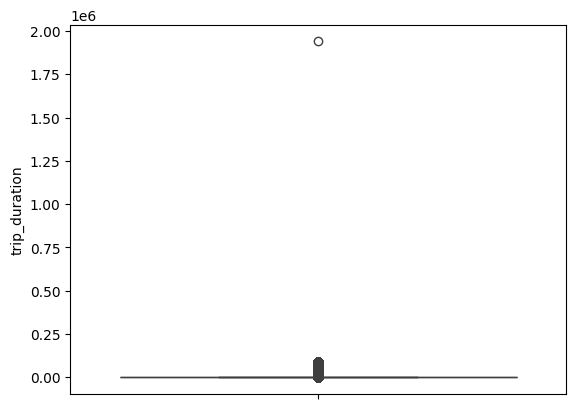

In [16]:
sns.boxplot(df["trip_duration"])

In [17]:
df["trip_duration_log"] = np.log1p(df["trip_duration"])

<Axes: ylabel='trip_duration_log'>

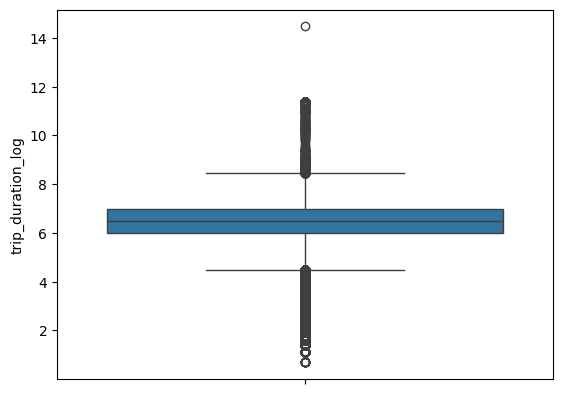

In [18]:
sns.boxplot(df["trip_duration_log"])

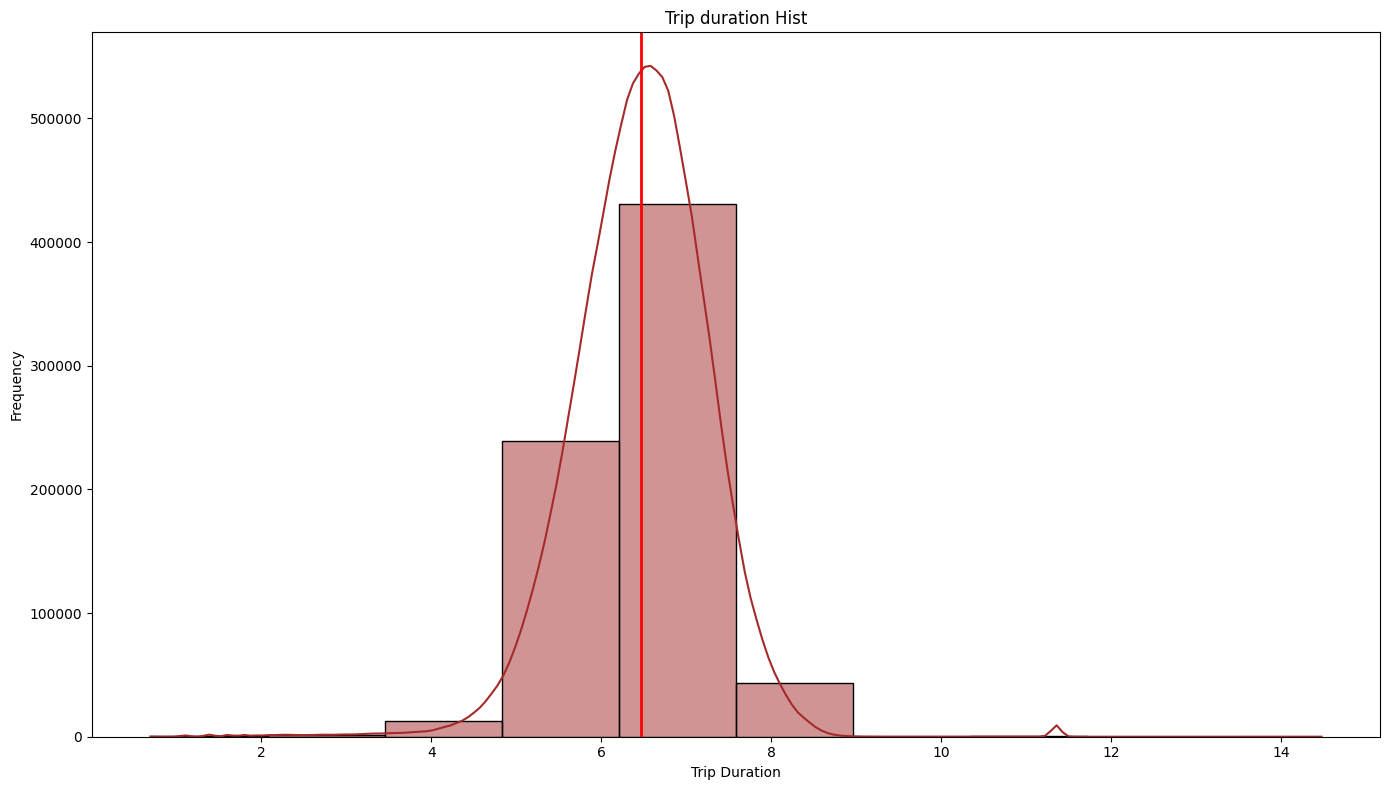

In [19]:
plt.figure(figsize=(14,8))

sns.histplot(df["trip_duration_log"], kde=True, bins=10, color="brown", edgecolor="black")
plt.axvline(df["trip_duration_log"].mean(), color="red", linewidth=2, label='Mean')


plt.title("Trip duration Hist")
plt.xlabel("Trip Duration")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

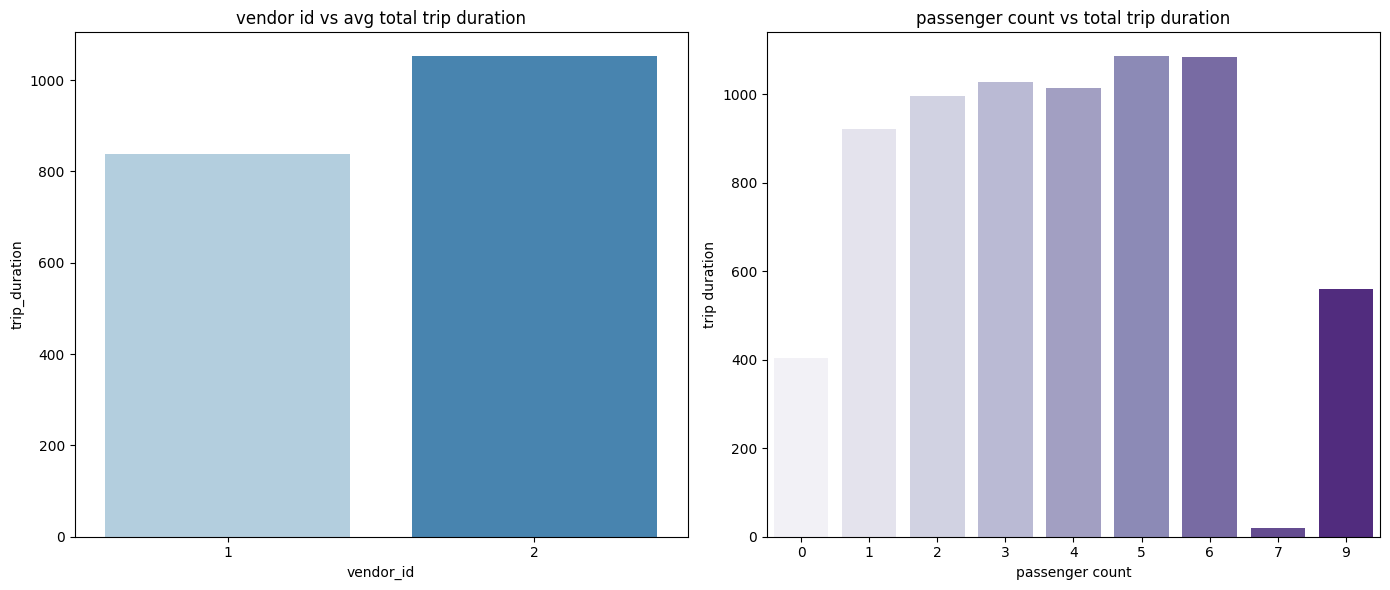

In [20]:
sum_vendor_group = df.groupby("vendor_id")["trip_duration"].mean().reset_index()
total_ride_duration_passengers = df.groupby("passenger_count")["trip_duration"].mean().reset_index()

fig, axes = plt.subplots(1,2, figsize=(14,6))

sns.barplot(data=sum_vendor_group, x="vendor_id", y="trip_duration", palette="Blues", ax=axes[0])
axes[0].set_title("vendor id vs avg total trip duration")
axes[0].set_xlabel("vendor_id")
axes[0].set_ylabel("trip_duration")

sns.barplot(data=total_ride_duration_passengers, x="passenger_count", y="trip_duration", palette="Purples", ax=axes[1])
axes[1].set_title("passenger count vs total trip duration")
axes[1].set_xlabel("passenger count")
axes[1].set_ylabel("trip duration")

plt.tight_layout()
plt.show()

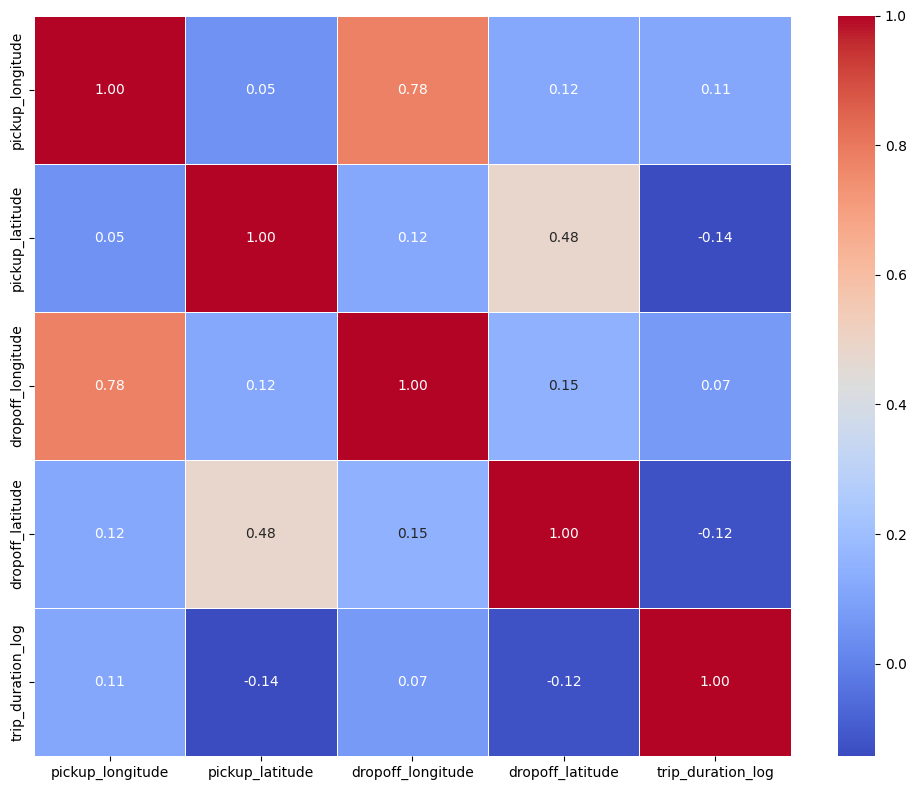

In [21]:
samples = df[["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude", 'trip_duration_log']]

corr_matrix = samples.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt='.2f', linewidths=0.5)
plt.tight_layout()
plt.show()

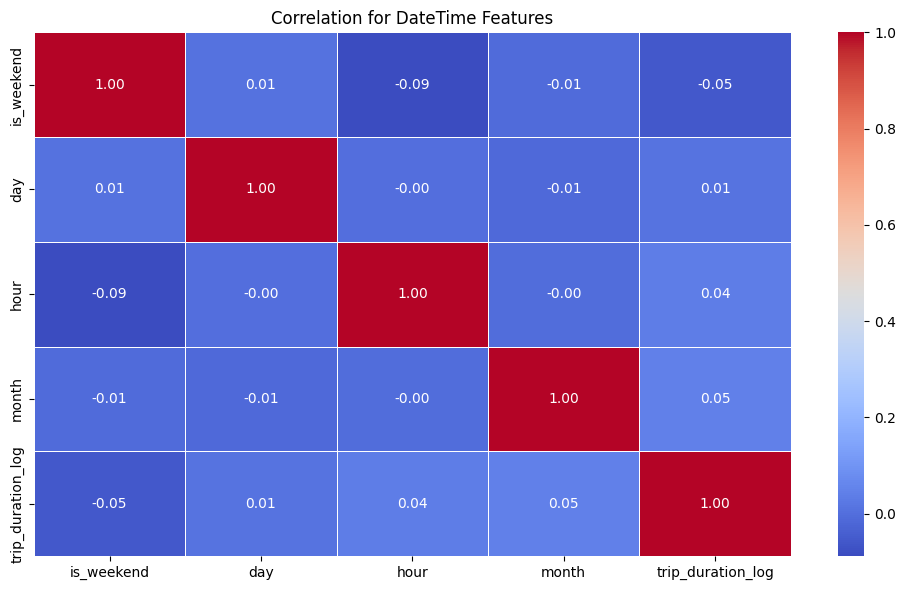

In [22]:
dt_corr = df[['is_weekend', 'day', 'hour', 'month', 'trip_duration_log']]

corr_matrix = dt_corr.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation for DateTime Features')
plt.tight_layout()
plt.show()

In [23]:
print("Minimum:", df["trip_duration"].min())
print("Maximum:", df["trip_duration"].max())

Minimum: 1
Maximum: 1939736


In [24]:
print("Minimum:", df["pickup_latitude"].min())
print("Maximum:", df["pickup_latitude"].max())

print("Minimum:", df["pickup_longitude"].min())
print("Maximum:", df["pickup_longitude"].max())

print("Minimum:", df["dropoff_latitude"].min())
print("Maximum:", df["dropoff_latitude"].max())

print("Minimum:", df["dropoff_longitude"].min())
print("Maximum:", df["dropoff_longitude"].max())

Minimum: 34.71223449707032
Maximum: 51.88108444213867
Minimum: -121.93334197998048
Maximum: -65.89738464355469
Minimum: 32.1811408996582
Maximum: 43.92102813720703
Minimum: -121.9333038330078
Maximum: -65.89738464355469


In [25]:
df = df[(df['pickup_latitude'].between(40.5, 41.0)) & 
        (df['pickup_longitude'].between(-74.05, -73.7))]
df = df[(df['dropoff_latitude'].between(40.5, 41.0)) & 
        (df['dropoff_longitude'].between(-74.05, -73.7))]

In [26]:
df["trip_duration"].describe()

count    7.270340e+05
mean     9.478490e+02
std      3.862935e+03
min      1.000000e+00
25%      3.960000e+02
50%      6.610000e+02
75%      1.071000e+03
max      1.939736e+06
Name: trip_duration, dtype: float64

In [27]:
outliers = df[
    (df["trip_duration"] <= 60) |
    (df["trip_duration"] >= 12600)
]

df = df[df["trip_duration"] > 60]
df = df[df["trip_duration"] < 12600]

In [28]:
print("Number of outliers:", len(outliers))

Number of outliers: 5223


In [29]:
df["trip_duration"].describe()

count    721811.000000
mean        837.449704
std         650.864739
min          61.000000
25%         400.000000
50%         664.000000
75%        1072.000000
max       12419.000000
Name: trip_duration, dtype: float64

In [30]:
df.corr(numeric_only=True)["trip_duration"].sort_values(ascending=False)

trip_duration         1.000000
trip_duration_log     0.885843
distance              0.765645
pickup_longitude      0.369675
dropoff_longitude     0.269504
month                 0.060934
store_and_fwd_flag    0.030936
hour                  0.029697
passenger_count       0.014088
day                   0.010632
vendor_id             0.006602
weekday              -0.033708
is_weekend           -0.064272
dropoff_latitude     -0.182054
pickup_latitude      -0.240334
Name: trip_duration, dtype: float64

In [31]:
df["passenger_count"].value_counts().sort_index()

passenger_count
0        10
1    511874
2    104124
3     29435
4     13920
5     38556
6     23891
9         1
Name: count, dtype: int64

In [32]:
df = df[(df["passenger_count"] >= 1) & (df["passenger_count"] <= 6)]

In [33]:
df["passenger_count"].value_counts().sort_index()

passenger_count
1    511874
2    104124
3     29435
4     13920
5     38556
6     23891
Name: count, dtype: int64

In [34]:
df.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day,month,weekday,is_weekend,distance,trip_duration_log
0,2,2016-02-29 16:40:21,1,-73.953918,40.778873,-73.963875,40.771164,0,400,16,29,2,0,0,1.199073,5.993961
1,1,2016-03-11 23:35:37,2,-73.988312,40.731743,-73.994751,40.694931,0,1100,23,11,3,4,0,4.129111,7.003974
2,2,2016-02-21 17:59:33,2,-73.997314,40.721458,-73.948029,40.774918,0,1635,17,21,2,6,1,7.250753,7.400010
3,2,2016-01-05 09:44:31,6,-73.961670,40.759720,-73.956779,40.780628,0,1141,9,5,1,1,0,2.361097,7.040536
4,1,2016-02-17 06:42:23,1,-74.017120,40.708469,-73.988182,40.740631,0,848,6,17,2,2,0,4.328534,6.744059


In [35]:
X = df.drop(["trip_duration", "pickup_datetime","trip_duration_log"], axis=1)
y = np.log1p(df["trip_duration"])

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=00)

# Model Training

## XGBoost

In [37]:
xgb_model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=6,
    tree_method="hist",
    random_state=2
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=None, num_parallel_tree=None, ...)

In [38]:
y_pred_log_xgb = xgb_model.predict(X_test)

y_pred_xgb = np.expm1(y_pred_log_xgb)
y_test_real = np.expm1(y_test)

In [39]:
mae_xgb = mean_absolute_error(y_test_real, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_real, y_pred_xgb))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

r2 = r2_score(y_test_real, y_pred_xgb)
print("R2:", r2)

XGBoost MAE: 171.54465048988956
XGBoost RMSE: 288.3521250251228
R2: 0.8033626530221905


## Random Forest

In [40]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)


rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_jobs=-1, random_state=42)

In [41]:
y_pred_log_rf = rf_model.predict(X_test)

y_pred_rf = np.expm1(y_pred_log_rf)
y_test_real = np.expm1(y_test)

In [42]:
mae_rf = mean_absolute_error(y_test_real, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_real, y_pred_rf))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

r2 = r2_score(y_test_real, y_pred_rf)
print("R2:", r2)

Random Forest MAE: 191.64303021993035
Random Forest RMSE: 314.24861276778455
R2: 0.766457227371492


## LightGBM

In [43]:
lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030157 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1359
[LightGBM] [Info] Number of data points in the train set: 577440, number of used features: 13
[LightGBM] [Info] Start training from score 6.477623


LGBMRegressor(learning_rate=0.05, n_estimators=300, random_state=42)

In [44]:
y_pred_log_lgbm = lgbm_model.predict(X_test)

y_pred_lgbm = np.expm1(y_pred_log_lgbm)
y_test_real = np.expm1(y_test)

In [47]:
mae_lgbm = mean_absolute_error(y_test_real, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test_real, y_pred_lgbm))

print("LightGBM MAE:", mae_lgbm)
print("LightGBM RMSE:", rmse_lgbm)

r2 = r2_score(y_test_real, y_pred_lgbm)
print("R2:", r2)

LightGBM MAE: 187.3742473784626
LightGBM RMSE: 310.3619248132091
R2: 0.7721985066694943


## ExtraTreesRegressor

In [48]:
et_model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

et_model.fit(X_train, y_train)

ExtraTreesRegressor(max_depth=15, n_estimators=300, n_jobs=-1, random_state=42)

In [49]:
y_pred_log_et = et_model.predict(X_test)

y_pred_et = np.expm1(y_pred_log_et)
y_test_real = np.expm1(y_test)

In [50]:
mae_et = mean_absolute_error(y_test_real, y_pred_et)
rmse_et = np.sqrt(mean_squared_error(y_test_real, y_pred_et))

print("ExtraTreesRegressor MAE:", mae_et)
print("ExtraTreesRegressor RMSE:", rmse_et)

r2 = r2_score(y_test_real, y_pred_et)
print("R2:", r2)

ExtraTreesRegressor MAE: 204.6294374401271
ExtraTreesRegressor RMSE: 328.69728802453426
R2: 0.7444876270905583


## AdaBoostRegressor

In [51]:
ada_model = AdaBoostRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

ada_model.fit(X_train, y_train)

AdaBoostRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [52]:
y_pred_log_ada = ada_model.predict(X_test)

y_pred_ada = np.expm1(y_pred_log_ada)
y_test_real = np.expm1(y_test)

In [53]:
mae_ada = mean_absolute_error(y_test_real, y_pred_ada)
rmse_ada = np.sqrt(mean_squared_error(y_test_real, y_pred_ada))

print("AdaBoostRegressor MAE:", mae_ada)
print("AdaBoostRegressor RMSE:", rmse_ada)

r2 = r2_score(y_test_real, y_pred_ada)
print("R2:", r2)

AdaBoostRegressor MAE: 258.2879892342805
AdaBoostRegressor RMSE: 411.3988381068377
R2: 0.5997366599464461


## HistGradientBoostingRegressor

In [54]:
hgb_model = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_depth=10,
    max_iter=2000,
    random_state=42
)

hgb_model.fit(X_train, y_train)

HistGradientBoostingRegressor(learning_rate=0.03, max_depth=10, max_iter=2000,
                              random_state=42)

In [55]:
y_pred_log_hgb = hgb_model.predict(X_test)

y_pred_hgb = np.expm1(y_pred_log_hgb)
y_test_real = np.expm1(y_test)

In [56]:
mae_hgb = mean_absolute_error(y_test_real, y_pred_hgb)
rmse_hgb = np.sqrt(mean_squared_error(y_test_real, y_pred_hgb))

print("HistGradientBoostingRegressor MAE:", mae_hgb)
print("HistGradientBoostingRegressor RMSE:", rmse_hgb)

r2 = r2_score(y_test_real, y_pred_hgb)
print("R2:", r2)

HistGradientBoostingRegressor MAE: 174.15481750111476
HistGradientBoostingRegressor RMSE: 291.8604242489777
R2: 0.7985486823661805


## CatBoostRegressor

In [57]:
cat_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    verbose=0,
    random_state=4
)

cat_model.fit(X_train, y_train)

CatBoostRegressor(depth=6, iterations=2000, learning_rate=0.03, loss_function='RMSE', random_state=4, verbose=0)

In [58]:
y_pred_log_cat = cat_model.predict(X_test)

y_pred_cat = np.expm1(y_pred_log_cat)
y_test_real = np.expm1(y_test)

In [59]:
mae_cat = mean_absolute_error(y_test_real, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test_real, y_pred_cat))

print("CatBoostRegressor MAE:", mae_cat)
print("CatBoostRegressor RMSE:", rmse_cat)

r2 = r2_score(y_test_real, y_pred_cat)
print("R2:", r2)

CatBoostRegressor MAE: 180.2682269215018
CatBoostRegressor RMSE: 300.5083239361996
R2: 0.7864337086852106


## Ensemble Learning

In [60]:
final_pred_log = (
    0.70 * y_pred_log_xgb + 
    0.30 * y_pred_log_hgb    
)

final_pred_real = np.expm1(final_pred_log)
y_test_real = np.expm1(y_test)



mae = mean_absolute_error(y_test_real, final_pred_real)
rmse = np.sqrt(
    mean_squared_error(y_test_real, final_pred_real)
)
r2 = r2_score(y_test_real, final_pred_real)


print("Ensemble MAE:", mae)
print("Ensemble RMSE:", rmse)
print("R2 Score:", r2)

Ensemble MAE: 171.56102526517122
Ensemble RMSE: 288.5032764300655
R2 Score: 0.8031564481866738


In [63]:
joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(lgbm_model, 'lgbm_model.pkl')
joblib.dump(ada_model, 'ada_model.pkl')
joblib.dump(hgb_model, 'hgb_model.pkl')
joblib.dump(et_model, 'et_model.pkl')
joblib.dump(cat_model, 'cat_model.pkl')

print("All models saved successfully! Click the links below to download:")

models_files = [
    'xgb_model.pkl', 'rf_model.pkl', 'lgbm_model.pkl', 
    'ada_model.pkl', 'hgb_model.pkl', 'et_model.pkl', 'cat_model.pkl'
]

for file_name in models_files:
    display(FileLink(file_name))

All models saved successfully! Click the links below to download:


/kaggle/working/xgb_model.pkl

/kaggle/working/rf_model.pkl

/kaggle/working/lgbm_model.pkl

/kaggle/working/ada_model.pkl

/kaggle/working/hgb_model.pkl

/kaggle/working/et_model.pkl

/kaggle/working/cat_model.pkl